In [3]:
%load_ext autoreload
%autoreload 2
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io as sio
import os

from tvboptim.experimental.network_dynamics import Network, solve, prepare
from tvboptim.experimental.network_dynamics.dynamics.tvb import ReducedWongWang
from tvboptim.experimental.network_dynamics.coupling import LinearCoupling, DelayedLinearCoupling
from tvboptim.experimental.network_dynamics.graph import DenseDelayGraph
from tvboptim.experimental.network_dynamics.noise import AdditiveNoise
from tvboptim.experimental.network_dynamics.solvers import Heun, BoundedSolver
from tvboptim.observations.tvb_monitors import Bold, SubSampling
from tvboptim.observations import compute_fc, fc_corr, rmse
from tvboptim.data import load_structural_connectivity, load_functional_connectivity
from tvboptim.types import Parameter, BoundedParameter
from tvboptim.optim import OptaxOptimizer
from tvboptim.optim.callbacks import DefaultPrintCallback, PrintParameterCallback
import optax

from tvbsim.TVB.tvb_model_reference.src.Zerlaut_tvboptim_gKgNa import Zerlaut_TVBoptim_first_order, Zerlaut_TVBoptim_second_order

Failed to read module file 'C:\Users\Bruna\AppData\Local\Programs\Python\Python311\Lib\functools.py' for module 'functools': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\TVBOptim\.venv_jax_new\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\TVBOptim\.venv_jax_new\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bruna\AppData\Local\Programs\Python\Python311\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstr

In [4]:
def conversion(E_Na, E_K, E_L, g_L=None, g_Na=None):
    """
        Returns leak conductance values (g_K and g_Na) given leak reversal potentials
        and either g_L or g_Na.
    
        This function applies algebraic rearrangements to ensure current balance
        in a conductance-based model.
    
        :param E_Na: Sodium leak reversal potential.
        :param E_K: Potassium leak reversal potential.
        :param E_L: Leak reversal potential.
        :param g_L: Leak conductance (optional, mutually exclusive with g_Na).
        :param g_Na: Sodium conductance (optional, mutually exclusive with g_L).
        :return: (g_K, g_Na) tuple of potassium and sodium conductances.
    """
    if g_L is not None:
        g_K = g_L * (E_L - E_Na) / (E_K - E_Na)
        g_Na = g_L - g_K
        return g_K, g_Na
    g_L = g_Na * (E_Na - E_K) / (E_L - E_K)
    g_K = g_L - g_Na
    return g_K, g_Na

Failed to read module file 'C:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\TVBOptim\.venv_jax_new\src\tvboptim\tvboptim\src\tvboptim\experimental\network_dynamics\dynamics\base.py' for module 'tvboptim.experimental.network_dynamics.dynamics.base': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\TVBOptim\.venv_jax_new\Lib\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 219, in update_sources
    self.source_by_modname[new_modname] = f.read()
                                          ^^^^^^^^
  File "C:\Users\Bruna\AppData\Local\Programs\Python\Python311\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x9d in position 14066: character maps to <undefined>


In [5]:
E_L_e_start = -63.
E_L_i_start = -65.
E_L_e_ends = [-62.,-61,-60]
E_L_i_ends = [-64.]

E_K_e = -90.
E_K_i = -90.
E_Na_e = 50.
E_Na_i = 50.
potential_values = {'E_K_e':E_K_e, 'E_K_i':E_K_i, 'E_Na_e':E_Na_e, 'E_Na_i':E_Na_i}
g_L = 10.
simconfigs = []
g_K_e_nopsi,g_Na_e_nopsi = conversion(E_Na=E_Na_e, E_K=E_K_e, E_L=E_L_e_start, g_L=g_L)
g_K_i_nopsi,g_Na_i_nopsi = conversion(E_Na=E_Na_i, E_K=E_K_i, E_L=E_L_i_start, g_L=g_L)
params_nopsi = {'g_K_e':g_K_e_nopsi, 'g_Na_e':g_Na_e_nopsi, 'g_K_i':g_K_i_nopsi, 'g_Na_i':g_Na_i_nopsi, **potential_values}
params_psi_list = []
for E_L_e_end in E_L_e_ends:
    for E_L_i_end in E_L_i_ends:
        g_K_e_psi,g_Na_e_psi = conversion(E_Na=E_Na_e, E_K=E_K_e, E_L=E_L_e_end, g_Na=g_Na_e_nopsi)
        g_K_i_psi,g_Na_i_psi = conversion(E_Na=E_Na_i, E_K=E_K_i, E_L=E_L_i_end, g_Na=g_Na_i_nopsi)
    
        params_psi_list.append({
            'g_K_e':g_K_e_psi,
            'g_K_i':g_K_i_psi,
            'g_Na_e':g_Na_e_psi, 
            'g_Na_i':g_Na_i_psi,
            **potential_values})

print(params_nopsi)
print(params_psi_list)

{'g_K_e': 8.071428571428571, 'g_Na_e': 1.9285714285714288, 'g_K_i': 8.214285714285714, 'g_Na_i': 1.7857142857142865, 'E_K_e': -90.0, 'E_K_i': -90.0, 'E_Na_e': 50.0, 'E_Na_i': 50.0}
[{'g_K_e': 7.714285714285715, 'g_K_i': 7.829670329670334, 'g_Na_e': 1.9285714285714288, 'g_Na_i': 1.7857142857142865, 'E_K_e': -90.0, 'E_K_i': -90.0, 'E_Na_e': 50.0, 'E_Na_i': 50.0}, {'g_K_e': 7.381773399014779, 'g_K_i': 7.829670329670334, 'g_Na_e': 1.9285714285714288, 'g_Na_i': 1.7857142857142865, 'E_K_e': -90.0, 'E_K_i': -90.0, 'E_Na_e': 50.0, 'E_Na_i': 50.0}, {'g_K_e': 7.071428571428573, 'g_K_i': 7.829670329670334, 'g_Na_e': 1.9285714285714288, 'g_Na_i': 1.7857142857142865, 'E_K_e': -90.0, 'E_K_i': -90.0, 'E_Na_e': 50.0, 'E_Na_i': 50.0}]


In [6]:
# Set directory information
cluster_run = False # Set to True if running on cluster, False if running locally

if cluster_run:
    data_dir = "./tvbsim/TVB/tvb_model_reference/data/connectivity/enigma_dk68/"
else:
    data_dir = "./"

# Set dataset parameters
n_sub = 48
n_nodes = 68 # size of network for AAL90
conds = ['CTR', 'SCZ']
n_cond = len(conds) # number of conditions

# Simulation parameters
t1 = 314_000   # Simulation duration (ms) matching empirical data (=304_000) + transient time (~10_000 ms)
dt = 4.0      # Integration timestep (ms) matching original script
bold_TR = 2000.0 # BOLD sampling period (ms)
transient_lim = 5 # Number of time points to remove as transient (transient_lim * dt ms)
target_fic = 0.25  # FIC tuning parameter: Target excitatory activity level

# Gradient descent parameters
learning_rate = 0.0325
max_steps = 120

# Other parameters
n_tau = 2 # number of lags for lagged FC

def load_structural_connectivity(sc_filepath: str | None = None,
                                 tl_filepath: str | None = None,
                                 centers_filepath: str | None = None) -> tuple[np.ndarray, pd.DataFrame, list]:
    """
    Load the structural connectivity matrix from a .npy file.
    
    Parameters
    ----------
    sc_filepath (str | None): Filepath for the structural connectivity matrix (.mat format expected).
    tl_filepath (str | None): Filepath for the tract lengths file.
    centers_filepath (str | None): Filepath for the region centers file.

    Returns
    -------
    tuple[np.ndarray, pd.DataFrame, list]: A tuple containing the normalized structural connectivity matrix, tract lengths DataFrame, and region labels.
    """
    if sc_filepath is None or tl_filepath is None or centers_filepath is None:
        raise ValueError("All filepaths (connectome, tract lengths, region centers) must be provided.")
    
    # Weights
    SCR = sio.loadmat(sc_filepath)['matrix']
    # weights = SCR / np.max(SCR)
    weights = SCR/(np.sum(SCR,axis=0)+1e-12)
    # Delays
    lengths = pd.read_csv(tl_filepath)
    speed = 3.0
    delays = lengths / speed

    # Load region labels and coordinates
    df = pd.read_csv(
        centers_filepath,
        sep='\t',
        header=None,
        dtype={1: float, 2: float, 3: float},
        names=['label', 'x', 'y', 'z']
    )

    labels = df['label'].tolist()
    
    return weights, delays, labels


sc_path = os.path.join(data_dir, 'SC_EnigmadK68.mat')
tl_path = os.path.join(data_dir, 'tract_lengths.csv')
centers_path = os.path.join(data_dir, 'centers.txt')

weights, delays, labels = load_structural_connectivity(sc_filepath=sc_path, tl_filepath=tl_path, centers_filepath=centers_path)

# weights = np.loadtxt('./tvbsim/TVB/tvb_model_reference/data/connectivity/enigma_dk68/weights.txt')
# weights = weights/(np.sum(weights,axis=0)+1e-12)

# lengths = np.loadtxt('./tvbsim/TVB/tvb_model_reference/data/connectivity/enigma_dk68/tract_lengths.csv')
# delays = lengths / 4.0  # Convert tract lengths (mm) to delays (ms) at 3 m/s conduction velocity

# centers_path = './tvbsim/TVB/tvb_model_reference/data/connectivity/connectivity_68_QL20120814/centres.txt'
# labels = [line.split()[0] for line in open(centers_path) if line.strip()]

# # Functional connectivity: empirical correlation patterns from resting-state fMRI
# target_fc = load_functional_connectivity("./data/dk_average")

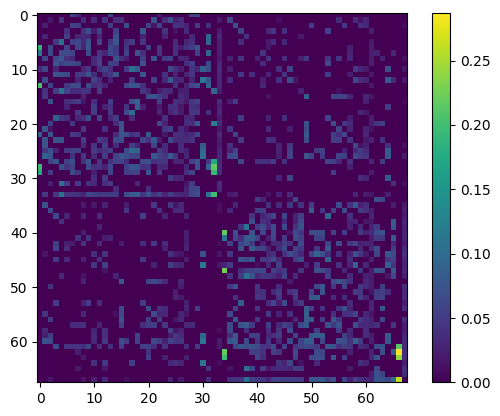

In [12]:
plt.imshow(weights)
plt.colorbar()

In [7]:
params_nopsi

{'g_K_e': 8.071428571428571,
 'g_Na_e': 1.9285714285714288,
 'g_K_i': 8.214285714285714,
 'g_Na_i': 1.7857142857142865,
 'E_K_e': -90.0,
 'E_K_i': -90.0,
 'E_Na_e': 50.0,
 'E_Na_i': 50.0}

In [7]:
results = {}
for params in [params_nopsi, *params_psi_list]:
    model = Zerlaut_TVBoptim_first_order()
   
    for key,value in params.items():
        model.DEFAULT_PARAMS[key] = value

    network = Network(
        dynamics=model,
        coupling={'delayed': DelayedLinearCoupling(
            incoming_states=["E","I"], G=0.3)},#, buffer_strategy='circular')},
            graph=DenseDelayGraph(
                weights,
                delays,
                region_labels=labels),
            noise=AdditiveNoise(sigma=1., apply_to="noise", key=jax.random.key(0))
    )
   
    # Run 60-second simulation (1 ms time steps)
    low_bounds = [1e-12,1e-12] + [-np.inf]*(len(model.STATE_NAMES)-2)
    high_bounds = [np.inf]*len(model.STATE_NAMES)
    solver = BoundedSolver(Heun(), low_bounds, high_bounds)
    solution = solve(network, solver, t0=0.0, t1=jnp.float64(t1), dt=jnp.float64(dt))
    results[(params['g_K_e'],params['g_K_i'])] = solution


import matplotlib.pyplot as plt

for params in [params_nopsi, *params_psi_list]:
    fig, ax = plt.subplots(figsize=(10, 3))
    # Get n colors from the viridis colormap

    ax.plot(results[(params['g_K_e'],params['g_K_i'])].ts, results[(params['g_K_e'],params['g_K_i'])].ys[:, 0],
        linewidth=0.8, alpha=0.9)
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Exc. FR (kHz)')
    ax.set_title(f'Neural activity trajectories ({n_nodes} example regions)\n{params["g_K_e"]}')
    plt.tight_layout()
    plt.show()
    plt.close()


c:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\TVBOptim\.venv_jax_new\Lib\site-packages\jax\_src\numpy\scalar_types.py:55: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return asarray(x, dtype=self.dtype)


TypeError: maximum requires ndarray or scalar arguments, got <class 'list'> at position 0.

In [19]:
results[1].data[20000,0]

Array([0.00430182, 0.00460077, 0.004939  , 0.00512906, 0.00470409,
       0.00520708, 0.00576643, 0.00522206, 0.00522658, 0.00513581,
       0.00555945, 0.00581227, 0.00461401, 0.00559579, 0.0051051 ,
       0.00484522, 0.0052887 , 0.00475435, 0.00383101, 0.00487456,
       0.00509513, 0.00468979, 0.00551841, 0.00550209, 0.00467918,
       0.00563221, 0.00569523, 0.00598967, 0.00487878, 0.00528108,
       0.0045513 , 0.00440451, 0.0034034 , 0.00542389, 0.00397267,
       0.0051749 , 0.00474283, 0.00523508, 0.00441949, 0.00467211,
       0.00494474, 0.00524812, 0.00565369, 0.00543035, 0.00555769,
       0.00501604, 0.00443163, 0.00485447, 0.00499317, 0.00497635,
       0.00532591, 0.00515997, 0.00465894, 0.00452544, 0.005381  ,
       0.00502839, 0.00527283, 0.00535923, 0.00505069, 0.00507718,
       0.00555564, 0.00602402, 0.00540666, 0.00543803, 0.00455227,
       0.00443672, 0.00465824, 0.00573714], dtype=float32)

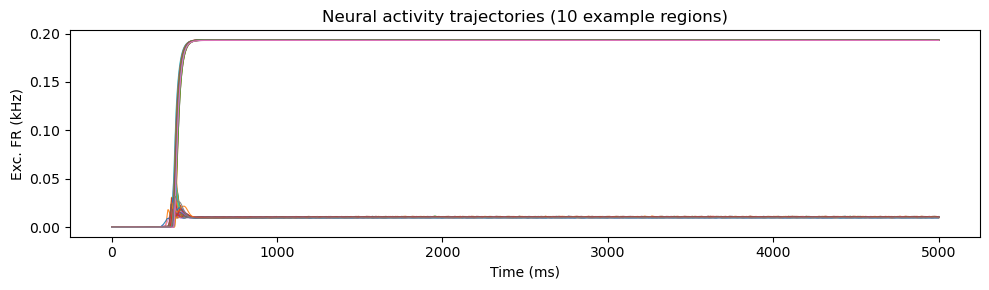

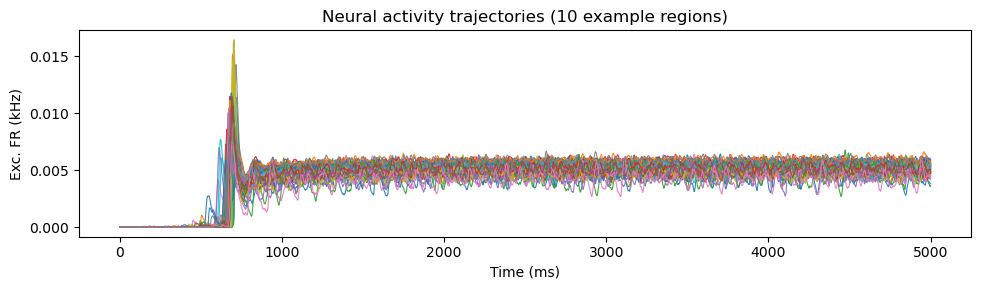

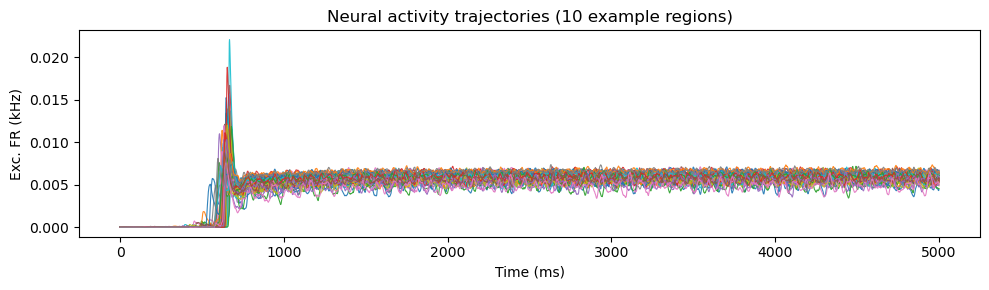

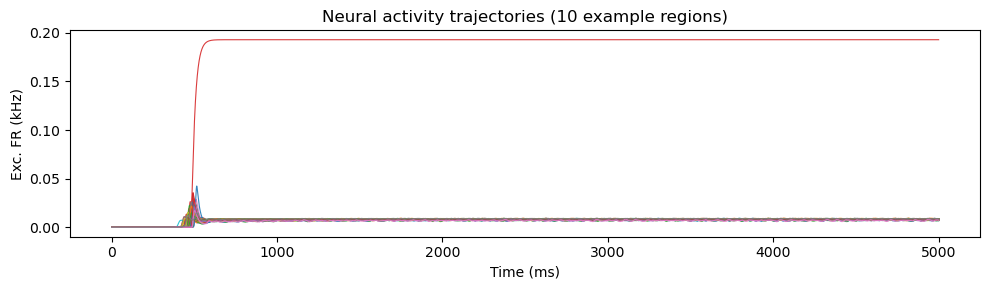

In [16]:
import matplotlib.pyplot as plt

for result in results:
    fig, ax = plt.subplots(figsize=(10, 3))
    # Get n colors from the viridis colormap
    n = 10
    ax.plot(result.ts, result.ys[:, 0], 
            linewidth=0.8, alpha=0.9)
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Exc. FR (kHz)')
    ax.set_title(f'Neural activity trajectories ({n} example regions)')
    plt.tight_layout()
    plt.show()
    plt.close()

In [40]:
target_fc_all = np.load('./tvbsim/TVB/tvb_model_reference/data/connectivity/enigma_dk68/Q0_emp_all.npy')
target_fc = target_fc_all[0,:,:,0]

In [12]:
# Optimization workflow: fit coupling strength to match empirical functional connectivity

# Step 1: Prepare for optimization by converting the network to pure function + parameters
network.update_history(result)  # Use simulation result to initialize delay history
simulator, params = prepare(network, solver, t0=0.0, t1=50_000.0, dt=0.1)

# Step 2: Set up BOLD fMRI monitor
# Converts neural activity to BOLD signal via Balloon-Windkessel hemodynamic model
# Sampled every 720 ms (≈1.4 Hz) to match typical fMRI temporal resolution
bold_monitor = Bold(history=result, period=2000.0, downsample=SubSampling(period=4.0))

# Step 3: Mark parameter for optimization
params.coupling.delayed.G = Parameter(0.3)

/tmp/ipykernel_92285/1612962586.py:10: DeprecationWarning: Bold is deprecated and will be removed in a future version. Use HRFBold (HRF convolution) or BalloonWindkesselBold (ODE integration) explicitly.
  bold_monitor = Bold(history=result, period=2000.0, downsample=SubSampling(period=4.0))


In [18]:
params.dynamics.b_e = BoundedParameter(5.0, low=0.0)

5.0

In [ ]:


# Compute initial FC for comparison
def get_fc(params):
    """Helper to compute FC from simulation."""
    solution = simulator(params)
    bold = bold_monitor(solution)
    return compute_fc(bold)

fc_initial = get_fc(params)

# Step 4: Define loss and optimize
def loss(params):
    """Loss function using RMSE between predicted and empirical FC."""
    predicted_fc = get_fc(params)
    return rmse(predicted_fc, target_fc)

# Run optimization with Adam optimizer
opt = OptaxOptimizer(loss, optax.adam(learning_rate=0.03), callback=DefaultPrintCallback())
final_params, history = opt.run(params, max_steps=5)

# Compute final FC and print results
fc_final = get_fc(final_params)
print(f"\nOptimization complete: G={final_params.coupling.delayed.G:.3f}")

/tmp/ipykernel_14934/1087666759.py:11: DeprecationWarning: Bold is deprecated and will be removed in a future version. Use HRFBold (HRF convolution) or BalloonWindkesselBold (ODE integration) explicitly.
  bold_monitor = Bold(history=result, period=2000.0, downsample=SubSampling(period=4.0))
